# EXERCISE 2 - Background Replacement Pipeline

Cho một pipeline dùng để ghép ảnh (green-screen / chroma-key).

**Ràng buộc:** Chỉ được dùng
- `cv2.imread` và `cv2.cvtColor` (để đọc / đổi không gian màu ảnh)
- `matplotlib` (để hiển thị ảnh)
- toàn bộ `numpy` + `math`

Pipeline:

```
Input (bg_image1, ob_image, bg_image2)
        |
  Create Masking:
        Compute Different  -> difference_single_channel
        Compute Binary     -> binary_mask
        |
  Replace Background       -> Output
```

In [12]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

# Chi duoc dung cv2.imread va cv2.cvtColor tu OpenCV.
# Moi xu ly khac deu lam bang numpy + math.

## 1. Input - Đọc 3 ảnh đầu vào

- `bg_image1`: phông xanh (không có người)
- `ob_image` : phông xanh + đối tượng (người)
- `bg_image2`: phông nền mới sẽ thay vào

bg_image1: (699, 964, 3)
ob_image : (699, 964, 3)
bg_image2: (495, 880, 3)


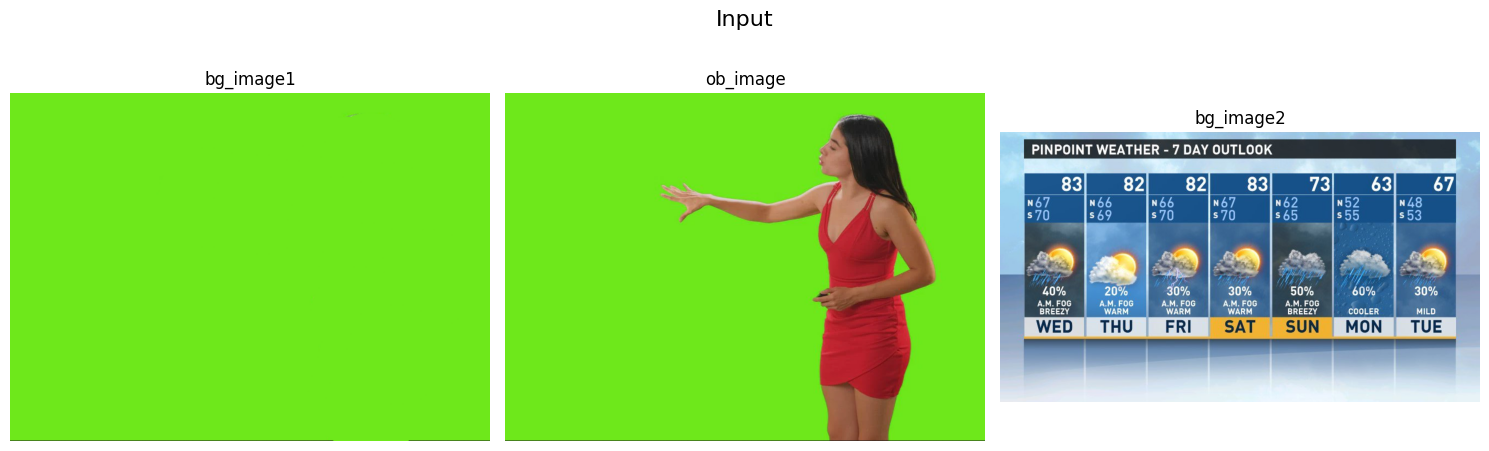

In [13]:
# cv2.imread tra ve anh dang BGR -> doi sang RGB bang cv2.cvtColor de hien thi dung mau
bg_image1 = cv2.cvtColor(cv2.imread('data/background1.png'), cv2.COLOR_BGR2RGB)
ob_image  = cv2.cvtColor(cv2.imread('data/object.png'),      cv2.COLOR_BGR2RGB)
bg_image2 = cv2.cvtColor(cv2.imread('data/background2.png'), cv2.COLOR_BGR2RGB)

print('bg_image1:', bg_image1.shape)
print('ob_image :', ob_image.shape)
print('bg_image2:', bg_image2.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(bg_image1); axes[0].set_title('bg_image1'); axes[0].axis('off')
axes[1].imshow(ob_image);  axes[1].set_title('ob_image');  axes[1].axis('off')
axes[2].imshow(bg_image2); axes[2].set_title('bg_image2'); axes[2].axis('off')
fig.suptitle('Input', fontsize=16)
plt.tight_layout(); plt.show()

## 2. Create Masking

### 2.1 Compute Different -> `difference_single_channel`

Lấy độ chênh lệch tuyệt đối giữa ảnh có đối tượng và ảnh phông nền, sau đó
gộp 3 kênh màu thành 1 kênh (lấy tổng / trung bình theo trục màu).
Vùng có người sẽ có giá trị chênh lệch lớn, vùng phông xanh ≈ 0.

difference_single_channel: (699, 964) min= 0 max= 361


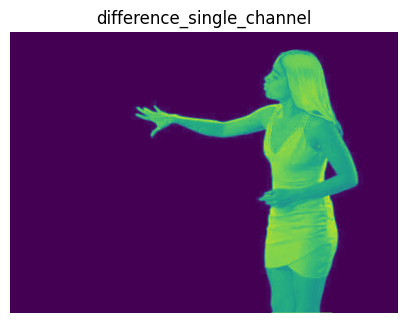

In [14]:
# Doi sang int de tru khong bi tran so (uint8 wrap-around)
a = ob_image.astype(np.int32)
b = bg_image1.astype(np.int32)

# |ob_image - bg_image1| tren tung kenh
difference = np.abs(a - b)

# Gop 3 kenh -> 1 kenh: tong cuong do chenh lech cua R,G,B
difference_single_channel = difference.sum(axis=2)

print('difference_single_channel:', difference_single_channel.shape,
      'min=', difference_single_channel.min(), 'max=', difference_single_channel.max())

plt.figure(figsize=(5, 5))
plt.imshow(difference_single_channel)   # colormap mac dinh (viridis): tim -> vang
plt.title('difference_single_channel')
plt.axis('off'); plt.show()

### 2.2 Compute Binary -> `binary_mask`

Đặt ngưỡng (threshold) trên ảnh chênh lệch 1 kênh:
- pixel chênh lệch > ngưỡng  -> thuộc đối tượng (1 / trắng)
- ngược lại                  -> thuộc phông nền (0 / đen)

Ty le pixel thuoc doi tuong: 18.03%


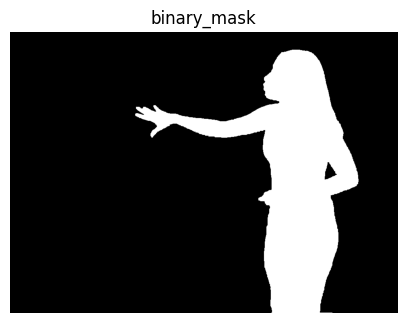

In [15]:
threshold = 60   # nguong tren tong chenh lech 3 kenh (0..765)

# binary_mask: True/1 tai vung doi tuong
binary_mask = (difference_single_channel > threshold).astype(np.uint8)

print('Ty le pixel thuoc doi tuong: {:.2f}%'.format(100.0 * binary_mask.mean()))

plt.figure(figsize=(5, 5))
plt.imshow(binary_mask * 255, cmap='gray', vmin=0, vmax=255)
plt.title('binary_mask')
plt.axis('off'); plt.show()

## 3. Replace Background

`bg_image2` có kích thước khác `ob_image` nên cần resize cho khớp.
Vì không được dùng `cv2.resize`, ta tự cài đặt resize bằng numpy
(nội suy gần nhất - nearest neighbor).

Sau đó ghép ảnh:
$$\text{output} = \text{mask} \cdot \text{ob\_image} + (1 - \text{mask}) \cdot \text{bg\_image2}$$

In [16]:
def resize_nearest(img, out_h, out_w):
    """Resize anh RGB bang nearest-neighbor, chi dung numpy + math."""
    in_h, in_w = img.shape[0], img.shape[1]
    # ti le anh xa toa do output -> input
    scale_y = in_h / out_h
    scale_x = in_w / out_w
    # toa do hang/cot tren anh goc cho tung pixel output
    ys = np.floor(np.arange(out_h) * scale_y).astype(np.int32)
    xs = np.floor(np.arange(out_w) * scale_x).astype(np.int32)
    ys = np.clip(ys, 0, in_h - 1)
    xs = np.clip(xs, 0, in_w - 1)
    # lay mau theo luoi chi so
    return img[ys[:, None], xs[None, :]]

H, W = ob_image.shape[0], ob_image.shape[1]
bg2_resized = resize_nearest(bg_image2, H, W)
print('bg_image2 resized:', bg2_resized.shape)

bg_image2 resized: (699, 964, 3)


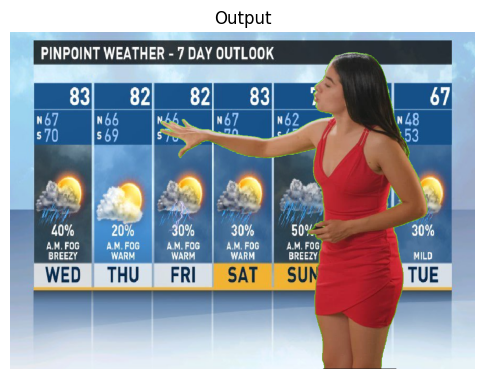

In [17]:
# Mo rong mask sang 3 kenh de nhan voi anh mau
mask3 = binary_mask[:, :, None]   # shape (H, W, 1) -> broadcast (H, W, 3)

# output = doi tuong o vung mask, nen moi o vung con lai
output = mask3 * ob_image + (1 - mask3) * bg2_resized
output = output.astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(output)
plt.title('Output')
plt.axis('off'); plt.show()

## 4. Tổng hợp toàn bộ pipeline

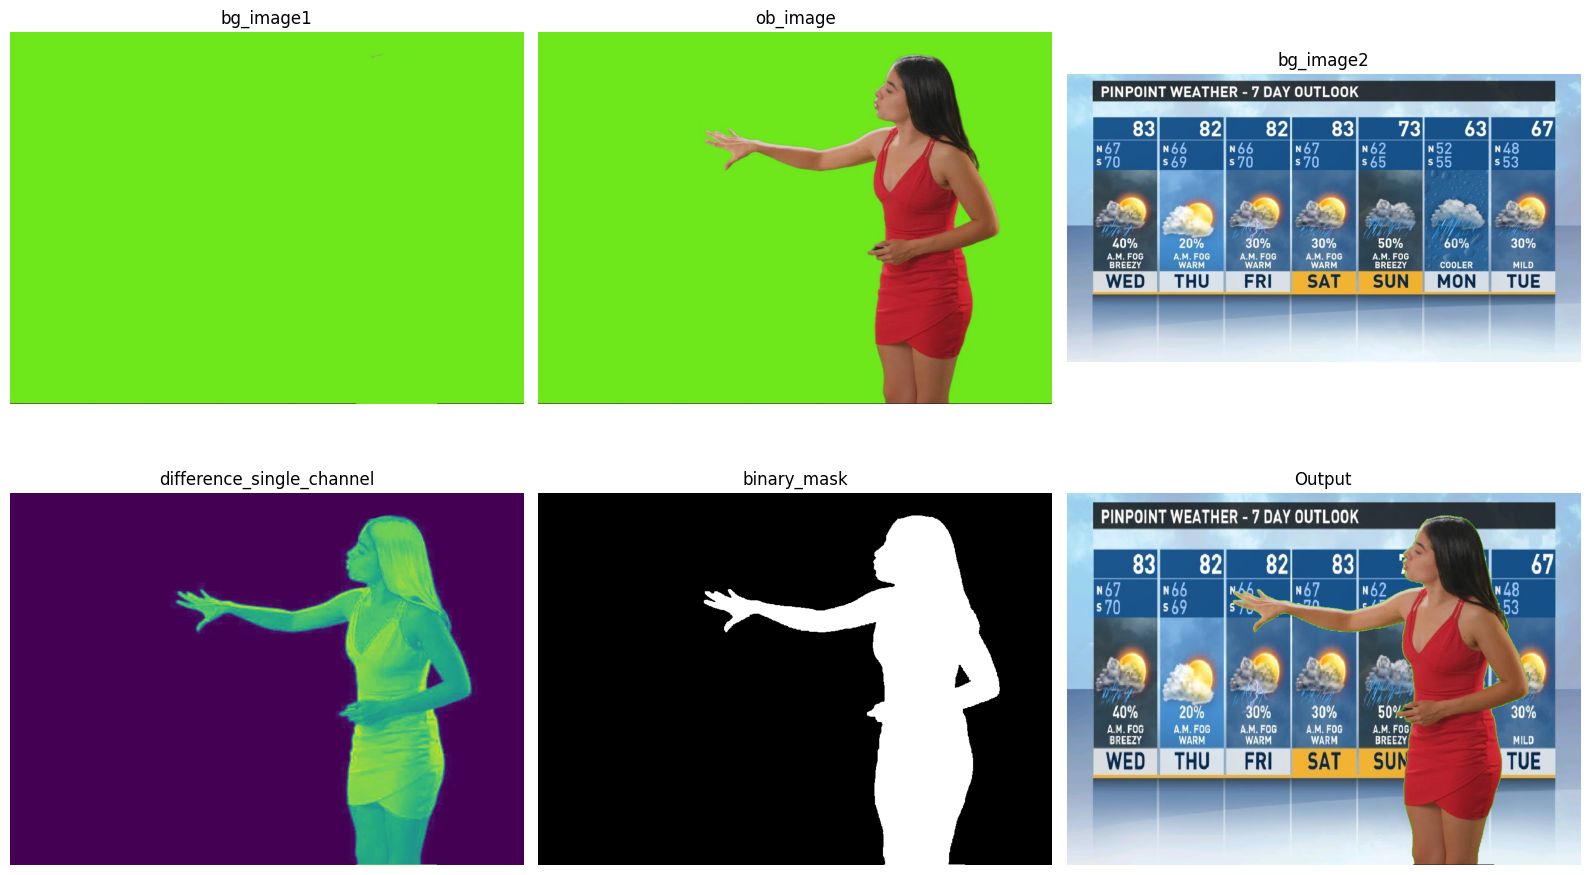

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(bg_image1); axes[0, 0].set_title('bg_image1'); axes[0, 0].axis('off')
axes[0, 1].imshow(ob_image);  axes[0, 1].set_title('ob_image');  axes[0, 1].axis('off')
axes[0, 2].imshow(bg_image2); axes[0, 2].set_title('bg_image2'); axes[0, 2].axis('off')

axes[1, 0].imshow(difference_single_channel)
axes[1, 0].set_title('difference_single_channel'); axes[1, 0].axis('off')
axes[1, 1].imshow(binary_mask * 255, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('binary_mask'); axes[1, 1].axis('off')
axes[1, 2].imshow(output); axes[1, 2].set_title('Output'); axes[1, 2].axis('off')

plt.tight_layout(); plt.show()